## DEMO: Script to visualize results on the Held-Out Teknon Test set

### 0. Requirements and libraries

Uncomment the first line to install all the requirements of the project.

In [1]:
#!pip install -r requirements.txt --upgrade

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal
import pickle

# 4. Scikit-Learn & Machine Learning
from sklearn.metrics import (
    ConfusionMatrixDisplay,classification_report)
from sklearn.preprocessing import normalize

### 1. Load Dataset

In [2]:
teknon = pickle.load(open('../data/full_data_corrected_2024.pkl', 'rb'))

#A. CLINICAL DATA
#Using all the patients in data (first keys), create a .csv with these subkeys:
subkeys = ['Sex', 'HTA', 'Age', 'PVC_transition', 'SOO_chamber', 'Height', 'Weight', 'BMI', 'DM', 'DLP', 'Smoker', 'COPD', 'Sleep_apnea', 'CLINICAL_SCORE', 'SOO', 'OTorigin'] #clinical data info - the clinical score is the weighted hybrid score of the patient - not recommend to use it since it gives RVOT or LVOT

#OTorigin is 1 if "OT" is in the SOO_chamber, otherwise 0. This is not the final RVOT/LVOT origin label, which you will have to build! :)
print(teknon.keys())
clinical_df = pd.DataFrame(columns=subkeys)

#Each clinical subkey is a key of the teknon dictionary
for subkey in subkeys:
    clinical_data = teknon[subkey]
    #This is now a column of the dataframe
    clinical_df[subkey] = clinical_data

soo_final = pd.read_csv('../soo_standarization/standarized_SOO.csv', sep=';')
chamber_final = pd.read_csv('../soo_standarization/soo_chamber_standarized_corregit.csv', sep=';')

soo_final.columns = ['Fila_Original', 'SOO_Nou']
chamber_final.columns = ['Fila_Original', 'SOO_Chamber_Nou']

df_nous_valors = pd.merge(soo_final, chamber_final, on='Fila_Original', how='left')
df_nous_valors.set_index('Fila_Original', inplace=True)

clinical_df['SOO'] = df_nous_valors['SOO_Nou']
clinical_df['SOO_chamber'] = df_nous_valors['SOO_Chamber_Nou']

dict_keys(['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'Sex', 'HTA', 'Age', 'PVC_transition', 'SOO_chamber', 'Height', 'Weight', 'BMI', 'DM', 'DLP', 'Smoker', 'COPD', 'Sleep_apnea', 'CLINICAL_SCORE', 'SOO', 'OTorigin'])


In [3]:
test_set = clinical_df.iloc[int(0.8*len(clinical_df)):] #test set

### 2. Upload final models for each task

In [4]:
output_folder = "../models"

#Binary model
binary_model_file = "best_model_binary_classification_Extra Trees_China_Teknon.pkl"
path_bin = os.path.join(output_folder, binary_model_file)

with open(path_bin, 'rb') as f:
    binary_model = pickle.load(f)

#Binary model
multi_model_file = "best_model_three_class_classification_SVM (RBF)_China_Teknon.pkl"
path_multi = os.path.join(output_folder, multi_model_file)

with open(path_multi, 'rb') as f:
    multi_model = pickle.load(f)

### 3. Evaluate Binary Classification model

              precision    recall  f1-score   support

           0       0.80      0.76      0.78        21
           1       0.71      0.75      0.73        16

    accuracy                           0.76        37
   macro avg       0.75      0.76      0.75        37
weighted avg       0.76      0.76      0.76        37



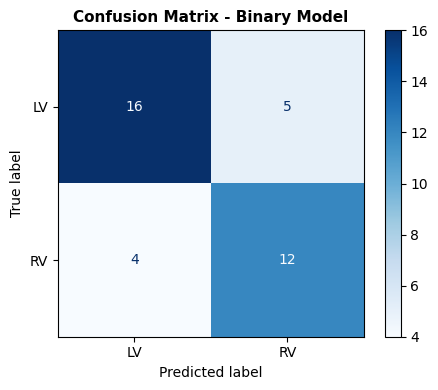

In [5]:
leads_tek = ["I","II","III","AVR","AVL","AVF",
             "V1","V2","V3","V4","V5","V6"]

sample_size = 10
n_patients = len(teknon[leads_tek[0]])

X_Teknon = np.zeros((n_patients, len(leads_tek)*sample_size))

for iLead, lead in enumerate(leads_tek):
    for i in range(n_patients):
        sig = np.asarray(teknon[lead][i]).squeeze()
        X_Teknon[i, iLead*sample_size:(iLead+1)*sample_size] = signal.resample(sig, sample_size)

X_Teknon = normalize(X_Teknon, norm="l1")

y_binary = clinical_df["SOO_chamber"].map({"LV":0, "RV":1}).to_numpy()

valid_mask = ~pd.isna(y_binary)

X_Teknon = X_Teknon[valid_mask]
y_binary = y_binary[valid_mask].astype(int)

split_idx = int(len(X_Teknon)*0.8)

X_test = X_Teknon[split_idx:]
y_test = y_binary[split_idx:]

y_pred = binary_model.predict(X_test)

print(classification_report(y_test, y_pred))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=['LV', 'RV'], 
    cmap='Blues',
    ax=ax
)
ax.set_title("Confusion Matrix - Binary Model", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Evaluate 3-Class Classification model

              precision    recall  f1-score   support

        RVOT       0.83      0.62      0.71        16
        Cusp       0.25      0.10      0.14        10
        LVOT       0.40      0.80      0.53        10

    accuracy                           0.53        36
   macro avg       0.49      0.51      0.46        36
weighted avg       0.55      0.53      0.51        36



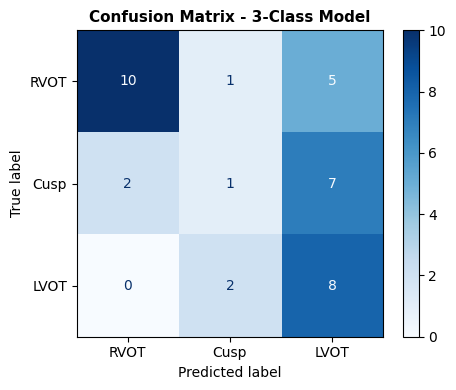

In [6]:
soo_str_to_3c = {
    'RVOT Septum': 0, 'RFW': 0,
    'LCC': 1, 'RCC': 1, 'COMMISSURE': 1,
    'LVOT Subvalvular': 2, 'LVOT Summit': 2
}

y_Tek3c_full = clinical_df['SOO'].map(soo_str_to_3c).to_numpy()
y_Tek3c_full = y_Tek3c_full[valid_mask]

mask_3c = ~pd.isna(y_Tek3c_full.astype(float))
X_Teknon_3c = X_Teknon[mask_3c]
y_Teknon_3c = y_Tek3c_full[mask_3c].astype(int)

split_3c_idx = int(len(X_Teknon_3c) * 0.8)
X_test = X_Teknon_3c[split_3c_idx:]
y_test = y_Teknon_3c[split_3c_idx:]

y_pred_multi = multi_model.predict(X_test)

print(classification_report(y_test, y_pred_multi, target_names=['RVOT', 'Cusp', 'LVOT']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_multi, 
    labels=[0, 1, 2],
    display_labels=['RVOT', 'Cusp', 'LVOT'], 
    cmap='Blues',
    ax=ax
)
ax.set_title("Confusion Matrix - 3-Class Model", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()